### Replicando para BR

In [1]:
# pip install yfinance pandas requests lxml openpyxl

import re
import time
import math
import requests
import pandas as pd
import yfinance as yf

HEADERS = {"User-Agent": "Mozilla/5.0"}

# ========= 1) Pegar universo (IBrX 100 ou Ibovespa) =========
def fetch_index_tickers(index: str = "IBRX") -> list[str]:
    """
    index:
      - "IBRX" -> IBrX 100 (carteira teórica)
      - "IBOV" -> Ibovespa (carteira teórica)
    Fonte: site antigo BM&FBOVESPA/B3 (bem parseável)
    """
    index = index.upper().strip()
    if index not in {"IBRX", "IBOV"}:
        raise ValueError("index deve ser 'IBRX' (IBrX 100) ou 'IBOV' (Ibovespa)")

    url = f"https://bvmf.bmfbovespa.com.br/indices/ResumoCarteiraTeorica.aspx?Indice={index}&idioma=pt-br"
    html = requests.get(url, headers=HEADERS, timeout=30).text

    # Tenta primeiro via read_html
    tickers = []
    try:
        tables = pd.read_html(html)
        for tb in tables:
            cols = [str(c).lower() for c in tb.columns]
            # geralmente a 1a coluna é "Código"
            if any("código" in c or "codigo" in c for c in cols):
                col = tb.columns[0]
                tickers = (
                    tb[col].astype(str)
                    .str.upper().str.strip()
                    .tolist()
                )
                break
    except ValueError:
        pass

    # Fallback por regex (pega coisas tipo PETR4, BPAC11, KLBN11 etc.)
    if not tickers:
        tickers = re.findall(r"\b[A-Z]{4}\d{1,2}\b", html)

    # Filtra e remove duplicatas mantendo ordem
    seen = set()
    out = []
    for t in tickers:
        t = t.strip().upper()
        if re.match(r"^[A-Z]{4}\d{1,2}$", t) and t not in seen:
            seen.add(t)
            out.append(t)

    return out

def to_yahoo_sa(tickers_b3: list[str]) -> list[str]:
    return [f"{t}.SA" if not t.endswith(".SA") else t for t in tickers_b3]


# ========= 2) Baixar preços (Close ajustado) em lotes =========
def chunked(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i+n]

def extract_close(df: pd.DataFrame, tickers_sa: list[str]) -> pd.DataFrame:
    """
    Normaliza a saída do yf.download para sempre retornar um DataFrame
    com colunas = tickers e valores = Close.
    """
    if df is None or df.empty:
        return pd.DataFrame()

    # Caso multi-ticker: geralmente vem MultiIndex com nível "Close"
    if isinstance(df.columns, pd.MultiIndex):
        # tenta no formato df["Close"]
        if "Close" in df.columns.get_level_values(0):
            close = df["Close"].copy()
            # garante só os tickers pedidos (às vezes vem coisa extra)
            close = close.loc[:, [c for c in close.columns if c in tickers_sa]]
            return close

        # fallback: procura nível com "Close"
        for level in range(df.columns.nlevels):
            if "Close" in df.columns.get_level_values(level):
                # tenta selecionar onde esse nível == Close
                close_cols = [c for c in df.columns if "Close" in c]
                close = df.loc[:, close_cols].copy()
                return close

    # Caso single-ticker
    if "Close" in df.columns:
        # Descobre ticker único (quando você passa 1 ativo)
        # e cria DF com coluna = ticker
        # Se não souber, usa "SINGLE"
        colname = tickers_sa[0] if tickers_sa else "SINGLE"
        return df[["Close"]].rename(columns={"Close": colname})

    return pd.DataFrame()

def download_closes(tickers_sa: list[str], start: str, end: str,
                    batch_size: int = 25, max_retries: int = 3, delay: int = 3) -> tuple[pd.DataFrame, list[str]]:
    """
    Baixa Close ajustado (auto_adjust=True) para uma lista de tickers .SA em lotes.
    Retorna (close_df, failures)
    """
    all_close = []
    failures = []

    for batch in chunked(tickers_sa, batch_size):
        got = None
        for attempt in range(1, max_retries + 1):
            try:
                df = yf.download(
                    tickers=batch,
                    start=start,
                    end=end,
                    auto_adjust=True,   # usa preços ajustados do Yahoo
                    progress=False,
                    threads=True,
                    timeout=30,
                    group_by="column"
                )
                got = extract_close(df, batch)
                break
            except Exception:
                if attempt == max_retries:
                    got = pd.DataFrame()
                else:
                    time.sleep(delay)

        # Se vier vazio, marca todos do batch como falha
        if got is None or got.empty:
            failures.extend(batch)
        else:
            # identifica tickers que não vieram
            missing = [t for t in batch if t not in got.columns]
            failures.extend(missing)
            # mantém só colunas ok
            got = got.loc[:, [c for c in got.columns if c in batch]]
            all_close.append(got)

    if not all_close:
        return pd.DataFrame(), sorted(set(failures))

    close_df = pd.concat(all_close, axis=1)
    # remove colunas duplicadas (se acontecer)
    close_df = close_df.loc[:, ~close_df.columns.duplicated()]
    close_df = close_df.sort_index()
    return close_df, sorted(set(failures))


def save_prices_csv(close_df: pd.DataFrame, filepath: str):
    close_df.to_csv(filepath, index=True)



In [2]:

# Escolha do universo (tanto faz, você disse): "IBRX" ou "IBOV"
#INDEX = "IBRX"  # recomendo IBrX 100
INDEX = "IBOV"

tickers_b3 = fetch_index_tickers(INDEX)
tickers_sa = to_yahoo_sa(tickers_b3)

print(f"Universo {INDEX}: {len(tickers_sa)} tickers")

# Períodos
start = "1997-01-02"

# 1997–2007 (end exclusivo)
end_2007 = "2008-01-01"
close_9707, fail_9707 = download_closes(tickers_sa, start, end_2007, batch_size=25)
print(f"[INFO] Tickers sem dados no Yahoo: {len(fail_9707)}")
save_prices_csv(close_9707, "precos_1997_2007.csv")
print("Salvo: precos_1997_2007.csv")

# 1997–2025 (end exclusivo)
end_2025 = "2026-01-01"
close_9725, fail_9725 = download_closes(tickers_sa, start, end_2025, batch_size=20)
print(f"[INFO] Tickers sem dados no Yahoo: {len(fail_9725)}")
save_prices_csv(close_9725, "precos_1997_2025.csv")
print("Salvo: precos_1997_2025.csv")

C:\Users\savio\AppData\Local\Temp\ipykernel_1504\1243103092.py:30: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


Universo IBOV: 81 tickers


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: CPLE6.SA"}}}

15 Failed downloads:
['BTOW3.SA', 'CIEL3.SA', 'BRDT3.SA', 'BRML3.SA', 'CPLE6.SA', 'CRFB3.SA', 'BRFS3.SA', 'CCRO3.SA']: YFTzMissingError('possibly delisted; no timezone found')
['BPAC11.SA', 'ASAI3.SA', 'CVCB3.SA', 'BBDC4.SA', 'COGN3.SA', 'AZUL4.SA', 'BBSE3.SA']: YFPricesMissingError('possibly delisted; no price data found  (1d 1997-01-02 -> 2008-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 852170400, endDate = 1199152800")')

16 Failed downloads:
['GOLL4.SA', 'ELET3.SA', 'ENBR3.SA', 'GNDI3.SA', 'EMBR3.SA', 'JBSS3.SA', 'ELET6.SA', 'IGTA3.SA', 'HGTX3.SA']: YFTzMissingError('possibly delisted; no timezone found')
['FLRY3.SA', 'EQTL3.SA', 'ENGI11.SA', 'IRBR3.SA', 'HYPE3.SA', 'HAPV3.SA', 'ECOR3.SA']: YFPricesMissingError('possibly delisted; no price data found  (1d 1997-01-02 -> 2008-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 85217

[INFO] Tickers sem dados no Yahoo: 0
Salvo: precos_1997_2007.csv



6 Failed downloads:
['CIEL3.SA', 'BTOW3.SA', 'BRML3.SA', 'BRDT3.SA', 'BRFS3.SA', 'CCRO3.SA']: YFTzMissingError('possibly delisted; no timezone found')

7 Failed downloads:
['ENBR3.SA', 'CPLE6.SA', 'GNDI3.SA', 'ELET3.SA', 'CRFB3.SA', 'EMBR3.SA', 'ELET6.SA']: YFTzMissingError('possibly delisted; no timezone found')

8 Failed downloads:
['LCAM3.SA', 'NTCO3.SA', 'MRFG3.SA', 'LAME4.SA', 'GOLL4.SA', 'JBSS3.SA', 'IGTA3.SA', 'HGTX3.SA']: YFTzMissingError('possibly delisted; no timezone found')

2 Failed downloads:
['VVAR3.SA', 'SULA11.SA']: YFTzMissingError('possibly delisted; no timezone found')


[INFO] Tickers sem dados no Yahoo: 0
Salvo: precos_1997_2025.csv


In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import bs4 as bs
import requests
import seaborn as sns
import requests
import time

from funcoes2 import (
    pca_portfolio_spy,
    pca_portfolio_spy_hedge,
    pca_portfolio_spy_var,
    pca_portfolio_spy_adaptive_pcs,
    stats_from_returns
)

from analise_estrategia import analyze_strategy 

In [ ]:
# import investpy

# # Pega TODAS as ações listadas no Brasil
# stocks_br = investpy.stocks.get_stocks(country='brazil')

# # Ver o DataFrame
# print(stocks_br.head()) 

# # Extrair símbolos
# tickers = stocks_br['symbol'].tolist()

# # Converter para formato yfinance
# tickers_yf = [t + '.SA' for t in tickers]

# print(f"Total: {len(tickers_yf)} ações")

  country           name                               full_name  \
0  brazil  ABC BRASIL PN                     Banco ABC Brasil SA   
1  brazil  BRASILAGRO ON                   BrasilAgro - Co ON NM   
2  brazil     RUMO ON NM  RUMO Logistica Operadora Multimodal SA   
3  brazil  ALPARGATAS ON                           Alpargatas SA   
4  brazil  ALPARGATAS PN                           Alpargatas SA   

           isin currency symbol  
0  BRABCBACNPR4      BRL  ABCB4  
1  BRAGROACNOR7      BRL  AGRO3  
2  BRRAILACNOR9      BRL  RAIL3  
3  BRALPAACNOR0      BRL  ALPA3  
4  BRALPAACNPR7      BRL  ALPA4  
Total: 749 ações


In [2]:
# Carregar dados
start_date = "2000-01-03"
end_date = "2007-12-31"

data = pd.read_csv("precos_1997_2007.csv", index_col=0)
data.index = pd.to_datetime(data.index)
data = data.sort_index()

returns = data.pct_change()
returns.dropna(inplace=True,axis=0, how='all')
returns.dropna(inplace=True,axis=1, how='any')
#returns = returns.loc[start_date:end_date]

# Ibovespa no Yahoo é ^BVSP
data_ibov = yf.download("^BVSP", start=start_date, end=end_date, auto_adjust=True, progress=False)["Close"]
data_ibov.index = pd.to_datetime(data_ibov.index).tz_localize(None)
data_ibov = data_ibov.sort_index()

returns_ibov = data_ibov.pct_change().dropna()
returns_ibov.name = "IBOV"

# Garantir que ambos os DataFrames tenham índices coerentes e ordenados (sem timezone)
returns.index     = pd.to_datetime(returns.index).tz_localize(None)
returns_ibov.index = pd.to_datetime(returns_ibov.index).tz_localize(None)
returns     = returns.sort_index()
returns_ibov = returns_ibov.sort_index()

C:\Users\savio\AppData\Local\Temp\ipykernel_8688\832888748.py:9: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change()


In [3]:
# pegar os tickers e atualizar os dados até 2025
tickers = data.columns.tolist()
len(tickers)

81

In [4]:
bad_tickers = []

for col in data.columns:
    p = data[col]
    if p.min() <= 0:
        bad_tickers.append(col)
        continue
    if (p.max() / p.min()) > 1e3:  # variação absurda de escala
        bad_tickers.append(col)

data = data.drop(columns=bad_tickers, errors="ignore")
returns = returns.drop(columns=bad_tickers, errors="ignore")

bad_tickers

['BRKM5.SA', 'CMIG4.SA', 'GGBR4.SA', 'LREN3.SA', 'UGPA3.SA']

In [5]:
bad_tickers += ['CPFE3.SA']
tickers = list(set(tickers) - set(bad_tickers))
data = data.drop(columns=set(bad_tickers), errors="ignore")
returns = returns.drop(columns=set(bad_tickers), errors="ignore")

len(tickers)

75

In [6]:
returns.head()

,BBAS3.SA,BBDC3.SA,BRAP4.SA,CSNA3.SA,CYRE3.SA,GOAU4.SA,ITSA4.SA,PETR3.SA,PETR4.SA,SBSP3.SA,USIM5.SA,VALE3.SA,VIVT3.SA,WEGE3.SA
Date,,,,,,,,,,,,,,
2000-01-04,-0.047561,-0.072728,-0.071429,0.014389,0.000000,-0.034482,-0.095477,-0.056123,-0.055319,-0.059288,-0.036458,-0.023810,-0.027083,-0.035093
2000-01-05,0.010243,0.033986,0.076923,0.053698,0.000000,-0.014286,0.083333,0.013514,-0.010090,-0.027828,0.095136,0.000000,0.011135,0.000000
2000-01-06,0.013942,0.015171,0.000000,0.045192,0.000000,0.010870,0.015384,-0.008000,-0.003458,-0.005014,0.090819,0.000000,0.022024,-0.090911
2000-01-07,-0.022500,0.017434,0.000000,-0.006440,0.000000,0.003584,-0.005049,0.008064,0.004566,0.014062,0.039819,0.036586,0.004974,0.000000
2000-01-10,0.054988,0.004897,0.000000,0.012037,0.021739,0.046428,0.035532,0.029333,0.020545,0.063153,0.103568,0.082353,0.061856,0.000000


Tempo : 2000-03-28 00:00:00
Tempo : 2000-03-29 00:00:00
Tempo : 2000-03-30 00:00:00
Tempo : 2000-03-31 00:00:00
Tempo : 2000-04-03 00:00:00
Tempo : 2000-04-04 00:00:00
Tempo : 2000-04-05 00:00:00
Tempo : 2000-04-06 00:00:00
Tempo : 2000-04-07 00:00:00
Tempo : 2000-04-10 00:00:00
Tempo : 2000-04-11 00:00:00
Tempo : 2000-04-12 00:00:00
Tempo : 2000-04-13 00:00:00
Tempo : 2000-04-14 00:00:00
Tempo : 2000-04-17 00:00:00
Tempo : 2000-04-18 00:00:00
Tempo : 2000-04-19 00:00:00
Tempo : 2000-04-20 00:00:00
Tempo : 2000-04-21 00:00:00
Tempo : 2000-04-24 00:00:00
Tempo : 2000-04-25 00:00:00
Tempo : 2000-04-26 00:00:00
Tempo : 2000-04-27 00:00:00
Tempo : 2000-04-28 00:00:00
Tempo : 2000-05-01 00:00:00
Tempo : 2000-05-02 00:00:00
Tempo : 2000-05-03 00:00:00
Tempo : 2000-05-04 00:00:00
Tempo : 2000-05-05 00:00:00
Tempo : 2000-05-08 00:00:00
Tempo : 2000-05-09 00:00:00
Tempo : 2000-05-10 00:00:00
Tempo : 2000-05-11 00:00:00
Tempo : 2000-05-12 00:00:00
Tempo : 2000-05-15 00:00:00
Tempo : 2000-05-16 0

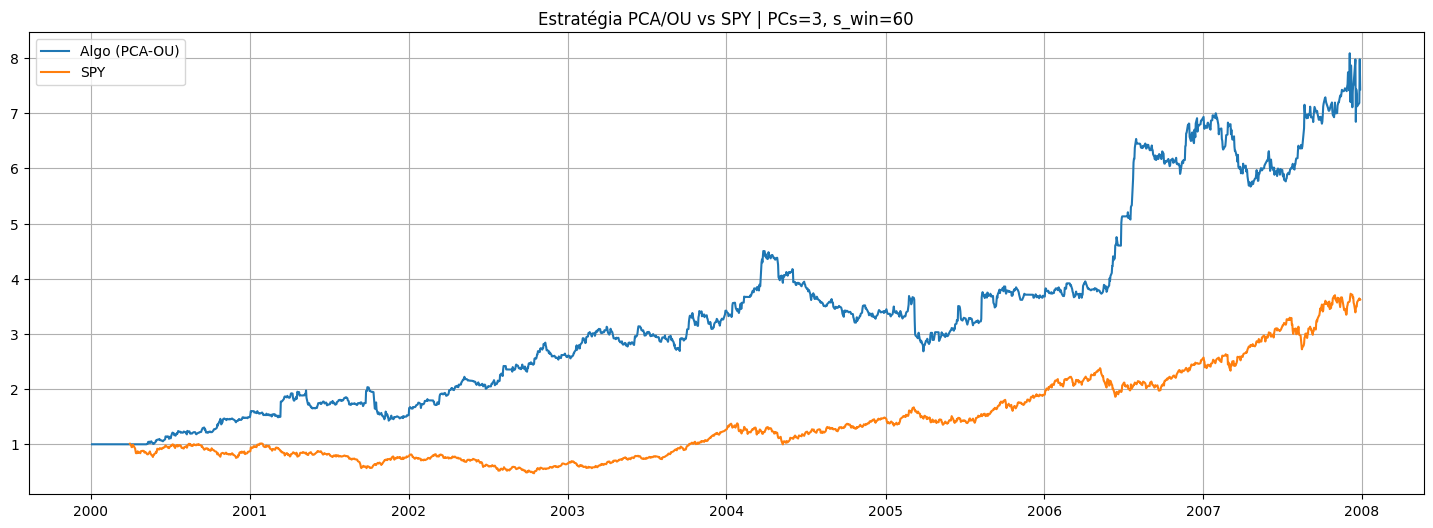

In [ ]:
# Melhor

results = pca_portfolio_spy(
    returns=returns,
    returns_spy=returns_ibov,
    num_pc=3,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,       
    plot=True
)


PERFORMANCE DA ESTRATÉGIA (1999-2007)
  CAGR      :     0.2789 (  27.89%)
  Vol       :     0.2693 (  26.93%)
  Sharpe    :     1.0356 ( 103.56%)
  MaxDD     :    -0.4037 ( -40.37%)


🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 
ANÁLISE DE NEUTRALIDADE DA ESTRATÉGIA
🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 


 Regredindo PnL contra fatores...

REGRESSÃO: RETORNO DA ESTRATÉGIA vs FATORES PCA
  R² (variância explicada por fatores): 0.0188 (1.88%)
  Alpha anualizado (excesso de retorno):  0.2812 (28.12%)
  Alpha diário médio:                      0.001116

  Beta médio (|valor|):                    0.1127
  Beta máximo (|valor|):                   0.2471 (fator: eig3)

📊 Interpretação:
  ✅ EXCELENTE: R² < 5% → Estratégia é genuinamente market-neutral!
     A maior parte do retorno vem de alpha idiossincrático.

  ✅ Alpha positivo (28.12%/ano) → Estratégia gera valor!


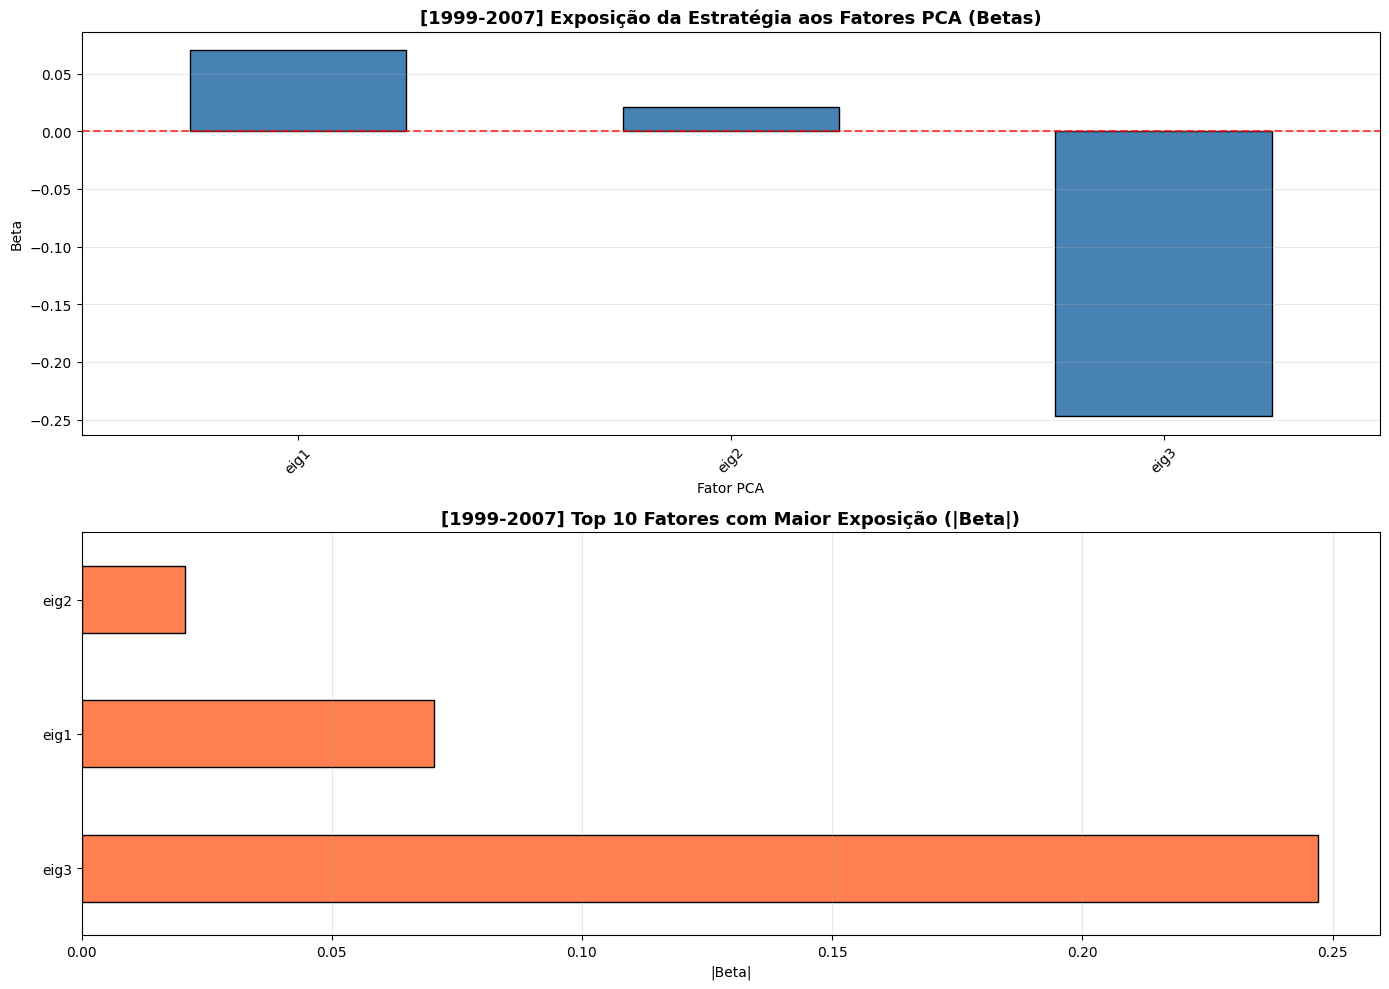


✅ Análise concluída!


📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 
ANÁLISE POR SUBPERÍODOS
📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 


Subperíodo: 1999-2002
  CAGR      :     0.3579 (  35.79%)
  Vol       :     0.2715 (  27.15%)
  Sharpe    :     1.3185 ( 131.85%)
  MaxDD     :    -0.2982 ( -29.82%)

Subperíodo: 2003-2007
  CAGR      :     0.2327 (  23.27%)
  Vol       :     0.2680 (  26.80%)
  Sharpe    :     0.8682 (  86.82%)
  MaxDD     :    -0.4037 ( -40.37%)


In [8]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net = results['ret_net']
stats = stats_from_returns(ret_net)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2007)")
print("="*70)
for k, v in stats.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")

# =============================================================================
# 4. ANÁLISE DE NEUTRALIDADE ⭐ NOVO
# =============================================================================

analysis_results = analyze_strategy(
    algo_weights=results['algo_weights'],
    betas=results['betas'],
    ret_net=results['ret_net'],
    Factor_PCA=results['Factor_PCA'],
    pcs=results['pcs'],
    plot=True,
    title_prefix="[1999-2007] "
)

# =============================================================================
# 5. ANÁLISE POR SUBPERÍODOS (OPCIONAL)
# =============================================================================

print("\n" + "📅 "*35)
print("ANÁLISE POR SUBPERÍODOS")
print("📅 "*35 + "\n")

subperiods = [
    ("1999-2002", "1999-01-01", "2002-12-31"),
    ("2003-2007", "2003-01-01", "2007-12-31"),
]

for label, start, end in subperiods:
    print(f"\n{'='*70}")
    print(f"Subperíodo: {label}")
    print(f"{'='*70}")
    
    mask = (ret_net.index >= start) & (ret_net.index <= end)
    ret_sub = ret_net[mask]
    
    if len(ret_sub) < 100:
        print("⚠️  Dados insuficientes")
        continue
    
    stats_sub = stats_from_returns(ret_sub)
    for k, v in stats_sub.items():
        print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")

Tempo : 2000-03-28 00:00:00
Tempo : 2000-03-29 00:00:00
Tempo : 2000-03-30 00:00:00
Tempo : 2000-03-31 00:00:00
Tempo : 2000-04-03 00:00:00
Tempo : 2000-04-04 00:00:00
Tempo : 2000-04-05 00:00:00
Tempo : 2000-04-06 00:00:00
Tempo : 2000-04-07 00:00:00
Tempo : 2000-04-10 00:00:00
Tempo : 2000-04-11 00:00:00
Tempo : 2000-04-12 00:00:00
Tempo : 2000-04-13 00:00:00
Tempo : 2000-04-14 00:00:00
Tempo : 2000-04-17 00:00:00
Tempo : 2000-04-18 00:00:00
Tempo : 2000-04-19 00:00:00
Tempo : 2000-04-20 00:00:00
Tempo : 2000-04-21 00:00:00
Tempo : 2000-04-24 00:00:00
Tempo : 2000-04-25 00:00:00
Tempo : 2000-04-26 00:00:00
Tempo : 2000-04-27 00:00:00
Tempo : 2000-04-28 00:00:00
Tempo : 2000-05-01 00:00:00
Tempo : 2000-05-02 00:00:00
Tempo : 2000-05-03 00:00:00
Tempo : 2000-05-04 00:00:00
Tempo : 2000-05-05 00:00:00
Tempo : 2000-05-08 00:00:00
Tempo : 2000-05-09 00:00:00
Tempo : 2000-05-10 00:00:00
Tempo : 2000-05-11 00:00:00
Tempo : 2000-05-12 00:00:00
Tempo : 2000-05-15 00:00:00
Tempo : 2000-05-16 0

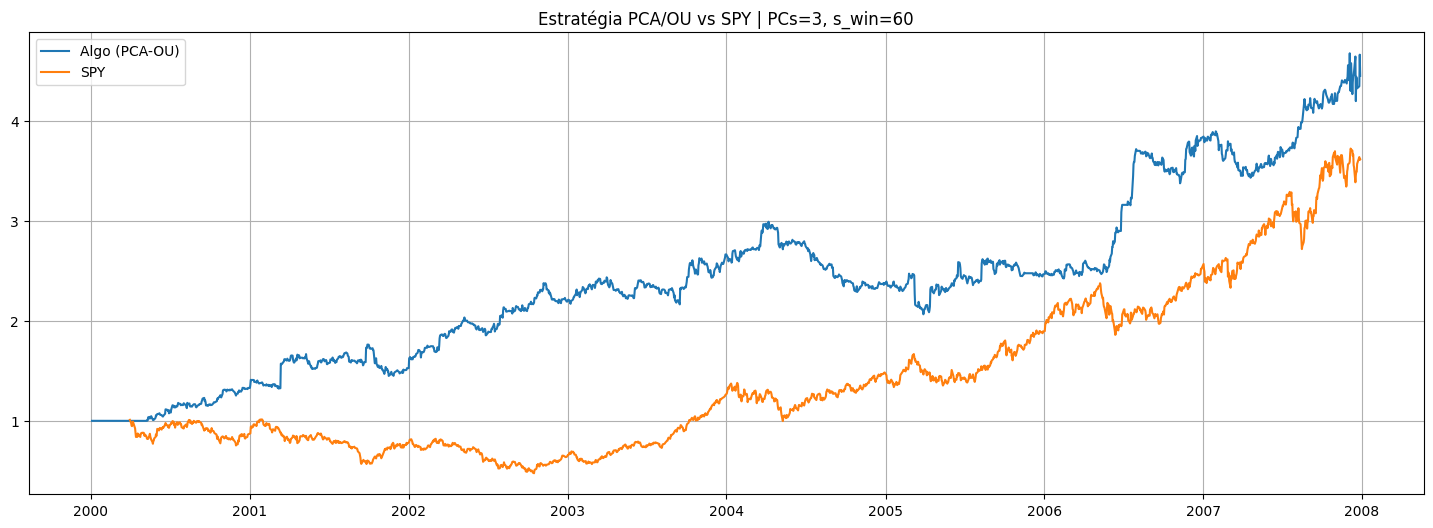

In [53]:
# Melhor

results2 = pca_portfolio_spy_hedge(
    returns=returns,
    returns_spy=returns_ibov,
    num_pc=3,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    #kappa_min=8.4, # padrão
    kappa_min=5.0,
    #kappa_min=10.0,
    plot=True
)


PERFORMANCE DA ESTRATÉGIA (1999-2007)
  CAGR      :     0.2012 (  20.12%)
  Vol       :     0.1949 (  19.49%)
  Sharpe    :     1.0323 ( 103.23%)
  MaxDD     :    -0.3096 ( -30.96%)


🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 
ANÁLISE DE NEUTRALIDADE DA ESTRATÉGIA
🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 


 Regredindo PnL contra fatores...

REGRESSÃO: RETORNO DA ESTRATÉGIA vs FATORES PCA
  R² (variância explicada por fatores): 0.0136 (1.36%)
  Alpha anualizado (excesso de retorno):  0.2054 (20.54%)
  Alpha diário médio:                      0.000815

  Beta médio (|valor|):                    0.0623
  Beta máximo (|valor|):                   0.1672 (fator: eig3)

📊 Interpretação:
  ✅ EXCELENTE: R² < 5% → Estratégia é genuinamente market-neutral!
     A maior parte do retorno vem de alpha idiossincrático.

  ✅ Alpha positivo (20.54%/ano) → Estratégia gera valor!


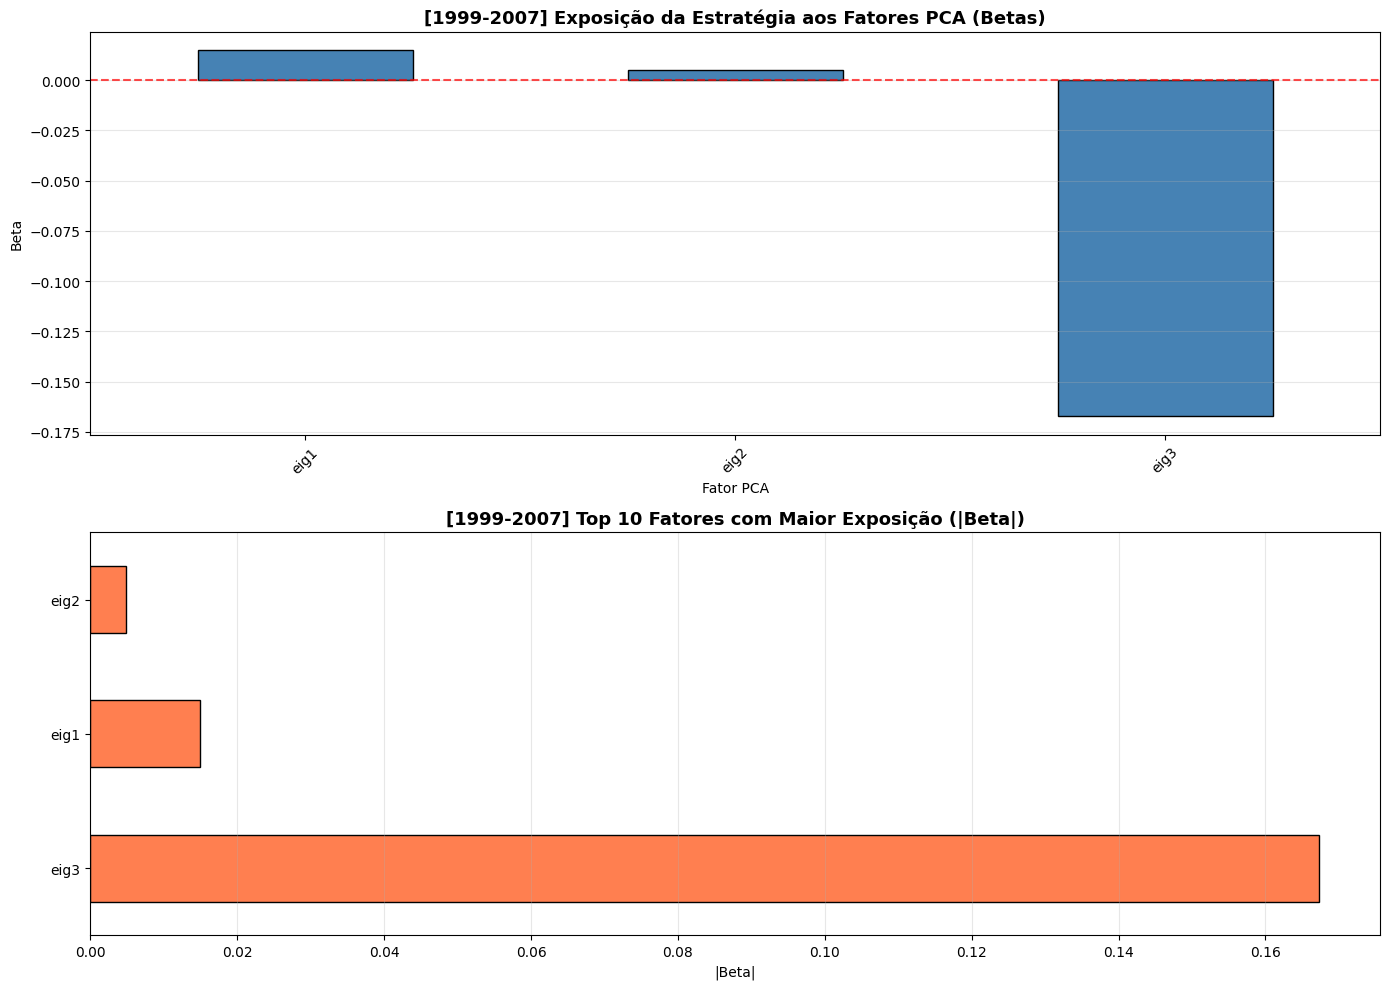


✅ Análise concluída!


📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 
ANÁLISE POR SUBPERÍODOS
📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 


Subperíodo: 1999-2002
  CAGR      :     0.2888 (  28.88%)
  Vol       :     0.2010 (  20.10%)
  Sharpe    :     1.4366 ( 143.66%)
  MaxDD     :    -0.1779 ( -17.79%)

Subperíodo: 2003-2007
  CAGR      :     0.1504 (  15.04%)
  Vol       :     0.1910 (  19.10%)
  Sharpe    :     0.7874 (  78.74%)
  MaxDD     :    -0.3096 ( -30.96%)


In [54]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net2 = results2['ret_net']
stats2 = stats_from_returns(ret_net2)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2007)")
print("="*70)
for k, v in stats2.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")

# =============================================================================
# 4. ANÁLISE DE NEUTRALIDADE ⭐ NOVO
# =============================================================================

analysis_results = analyze_strategy(
    algo_weights=results2['algo_weights'],
    betas=results2['betas'],
    ret_net=results2['ret_net'],
    Factor_PCA=results2['Factor_PCA'],
    pcs=results2['pcs'],
    plot=True,
    title_prefix="[1999-2007] "
)

# =============================================================================
# 5. ANÁLISE POR SUBPERÍODOS (OPCIONAL)
# =============================================================================

print("\n" + "📅 "*35)
print("ANÁLISE POR SUBPERÍODOS")
print("📅 "*35 + "\n")

subperiods2 = [
    ("1999-2002", "1999-01-01", "2002-12-31"),
    ("2003-2007", "2003-01-01", "2007-12-31"),
]

for label, start, end in subperiods2:
    print(f"\n{'='*70}")
    print(f"Subperíodo: {label}")
    print(f"{'='*70}")
    
    mask = (ret_net2.index >= start) & (ret_net2.index <= end)
    ret_sub = ret_net2[mask]
    
    if len(ret_sub) < 100:
        print("⚠️  Dados insuficientes")
        continue
    
    stats_sub = stats_from_returns(ret_sub)
    for k, v in stats_sub.items():
        print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")

Tempo : 2000-03-28 00:00:00
Tempo : 2000-03-29 00:00:00
Tempo : 2000-03-30 00:00:00
Tempo : 2000-03-31 00:00:00
Tempo : 2000-04-03 00:00:00
Tempo : 2000-04-04 00:00:00
Tempo : 2000-04-05 00:00:00
Tempo : 2000-04-06 00:00:00
Tempo : 2000-04-07 00:00:00
Tempo : 2000-04-10 00:00:00
Tempo : 2000-04-11 00:00:00
Tempo : 2000-04-12 00:00:00
Tempo : 2000-04-13 00:00:00
Tempo : 2000-04-14 00:00:00
Tempo : 2000-04-17 00:00:00
Tempo : 2000-04-18 00:00:00
Tempo : 2000-04-19 00:00:00
Tempo : 2000-04-20 00:00:00
Tempo : 2000-04-21 00:00:00
Tempo : 2000-04-24 00:00:00
Tempo : 2000-04-25 00:00:00
Tempo : 2000-04-26 00:00:00
Tempo : 2000-04-27 00:00:00
Tempo : 2000-04-28 00:00:00
Tempo : 2000-05-01 00:00:00
Tempo : 2000-05-02 00:00:00
Tempo : 2000-05-03 00:00:00
Tempo : 2000-05-04 00:00:00
Tempo : 2000-05-05 00:00:00
Tempo : 2000-05-08 00:00:00
Tempo : 2000-05-09 00:00:00
Tempo : 2000-05-10 00:00:00
Tempo : 2000-05-11 00:00:00
Tempo : 2000-05-12 00:00:00
Tempo : 2000-05-15 00:00:00
Tempo : 2000-05-16 0

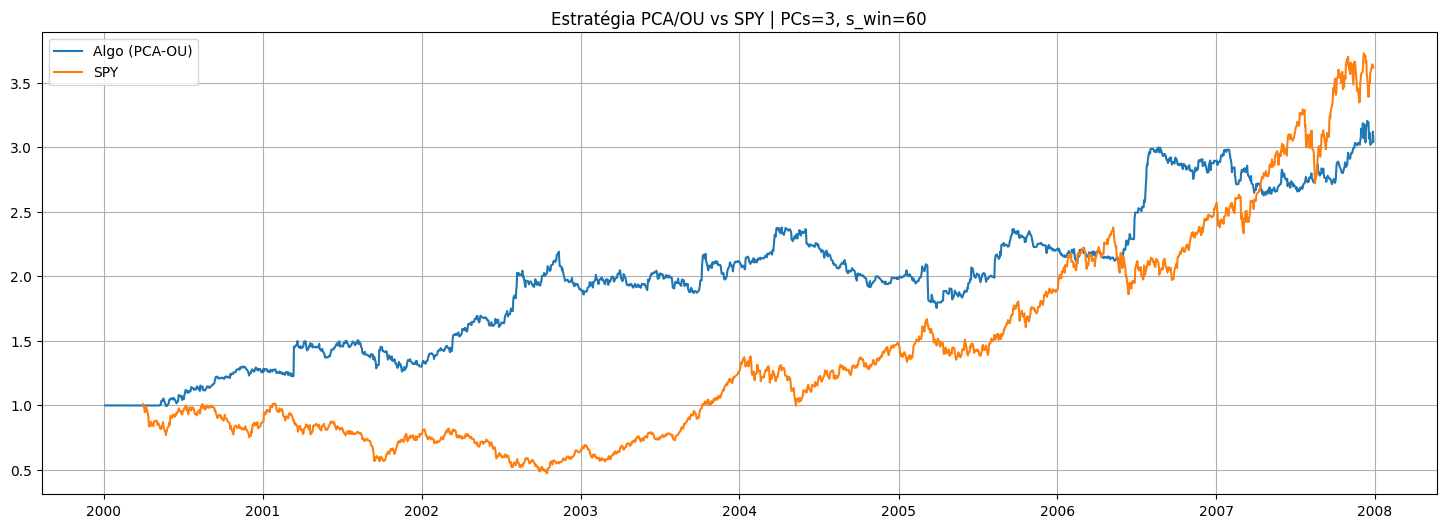

In [11]:
results3 = pca_portfolio_spy_var(
    returns=returns,
    returns_spy=returns_ibov,
    num_pc=3,
    s_win=60,
    adaptive_thresholds=True,
    adaptive_window=252,
    percentile_open=0.10,
    percentile_close_short=0.45,
    percentile_close_long=0.50,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True
)

Tempo : 2000-03-28 00:00:00
Tempo : 2000-03-29 00:00:00
Tempo : 2000-03-30 00:00:00
Tempo : 2000-03-31 00:00:00
Tempo : 2000-04-03 00:00:00
Tempo : 2000-04-04 00:00:00
Tempo : 2000-04-05 00:00:00
Tempo : 2000-04-06 00:00:00
Tempo : 2000-04-07 00:00:00
Tempo : 2000-04-10 00:00:00
Tempo : 2000-04-11 00:00:00
Tempo : 2000-04-12 00:00:00
Tempo : 2000-04-13 00:00:00
Tempo : 2000-04-14 00:00:00
Tempo : 2000-04-17 00:00:00
Tempo : 2000-04-18 00:00:00
Tempo : 2000-04-19 00:00:00
Tempo : 2000-04-20 00:00:00
Tempo : 2000-04-21 00:00:00
Tempo : 2000-04-24 00:00:00
Tempo : 2000-04-25 00:00:00
Tempo : 2000-04-26 00:00:00
Tempo : 2000-04-27 00:00:00
Tempo : 2000-04-28 00:00:00
Tempo : 2000-05-01 00:00:00
Tempo : 2000-05-02 00:00:00
Tempo : 2000-05-03 00:00:00
Tempo : 2000-05-04 00:00:00
Tempo : 2000-05-05 00:00:00
Tempo : 2000-05-08 00:00:00
Tempo : 2000-05-09 00:00:00
Tempo : 2000-05-10 00:00:00
Tempo : 2000-05-11 00:00:00
Tempo : 2000-05-12 00:00:00
Tempo : 2000-05-15 00:00:00
Tempo : 2000-05-16 0

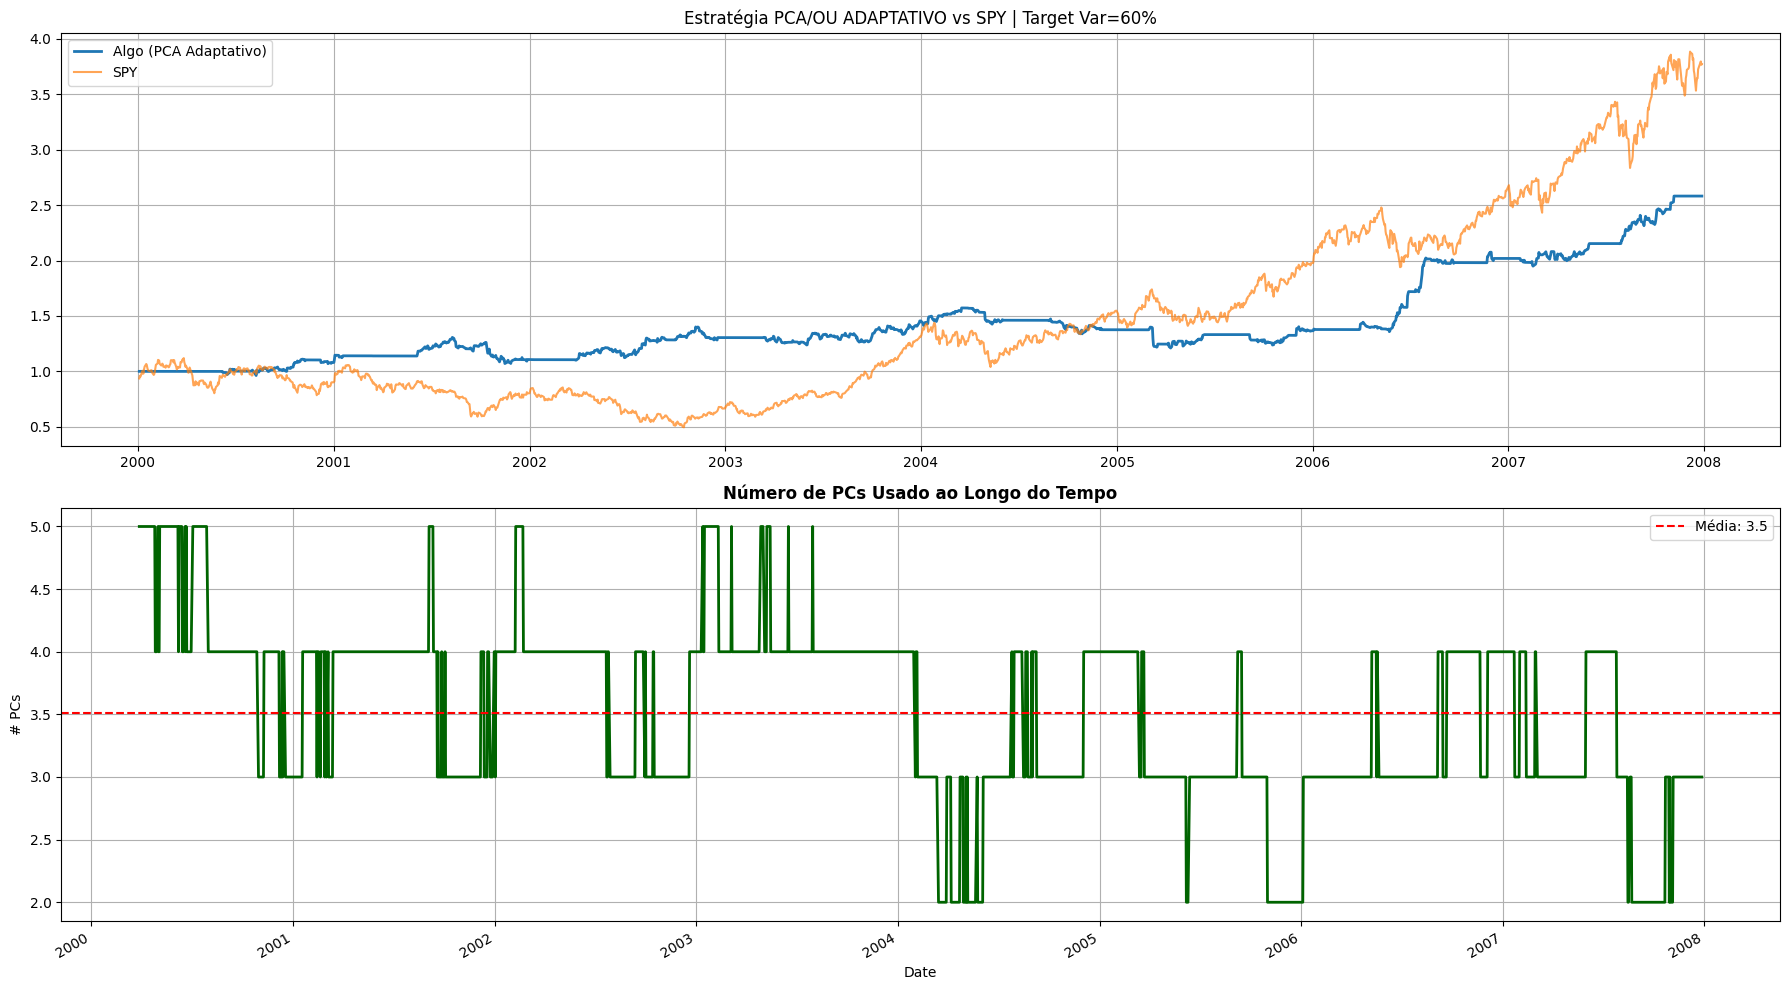

In [12]:
results4 = pca_portfolio_spy_adaptive_pcs(
    returns = returns,
    returns_spy = returns_ibov,
    variance_target = 0.60,  
    min_pcs = 1,
    max_pcs = 35,
    s_win = 60,
    adaptive_thresholds = False,
    adaptive_window = 252,
    percentile_open = 0.15,
    percentile_close_short = 0.35,
    percentile_close_long = 0.45,
    # thresholds fixos
    sbo = 1.25,
    sso = 1.25,
    sbc = 0.50,
    ssc = 0.50,
    eps_cost = 0.0005,
    rebalanceamento_dias = 1,
    plot = True,
)

Tempo : 2000-03-28 00:00:00
Tempo : 2000-03-29 00:00:00
Tempo : 2000-03-30 00:00:00
Tempo : 2000-03-31 00:00:00
Tempo : 2000-04-03 00:00:00
Tempo : 2000-04-04 00:00:00
Tempo : 2000-04-05 00:00:00
Tempo : 2000-04-06 00:00:00
Tempo : 2000-04-07 00:00:00
Tempo : 2000-04-10 00:00:00
Tempo : 2000-04-11 00:00:00
Tempo : 2000-04-12 00:00:00
Tempo : 2000-04-13 00:00:00
Tempo : 2000-04-14 00:00:00
Tempo : 2000-04-17 00:00:00
Tempo : 2000-04-18 00:00:00
Tempo : 2000-04-19 00:00:00
Tempo : 2000-04-20 00:00:00
Tempo : 2000-04-21 00:00:00
Tempo : 2000-04-24 00:00:00
Tempo : 2000-04-25 00:00:00
Tempo : 2000-04-26 00:00:00
Tempo : 2000-04-27 00:00:00
Tempo : 2000-04-28 00:00:00
Tempo : 2000-05-01 00:00:00
Tempo : 2000-05-02 00:00:00
Tempo : 2000-05-03 00:00:00
Tempo : 2000-05-04 00:00:00
Tempo : 2000-05-05 00:00:00
Tempo : 2000-05-08 00:00:00
Tempo : 2000-05-09 00:00:00
Tempo : 2000-05-10 00:00:00
Tempo : 2000-05-11 00:00:00
Tempo : 2000-05-12 00:00:00
Tempo : 2000-05-15 00:00:00
Tempo : 2000-05-16 0

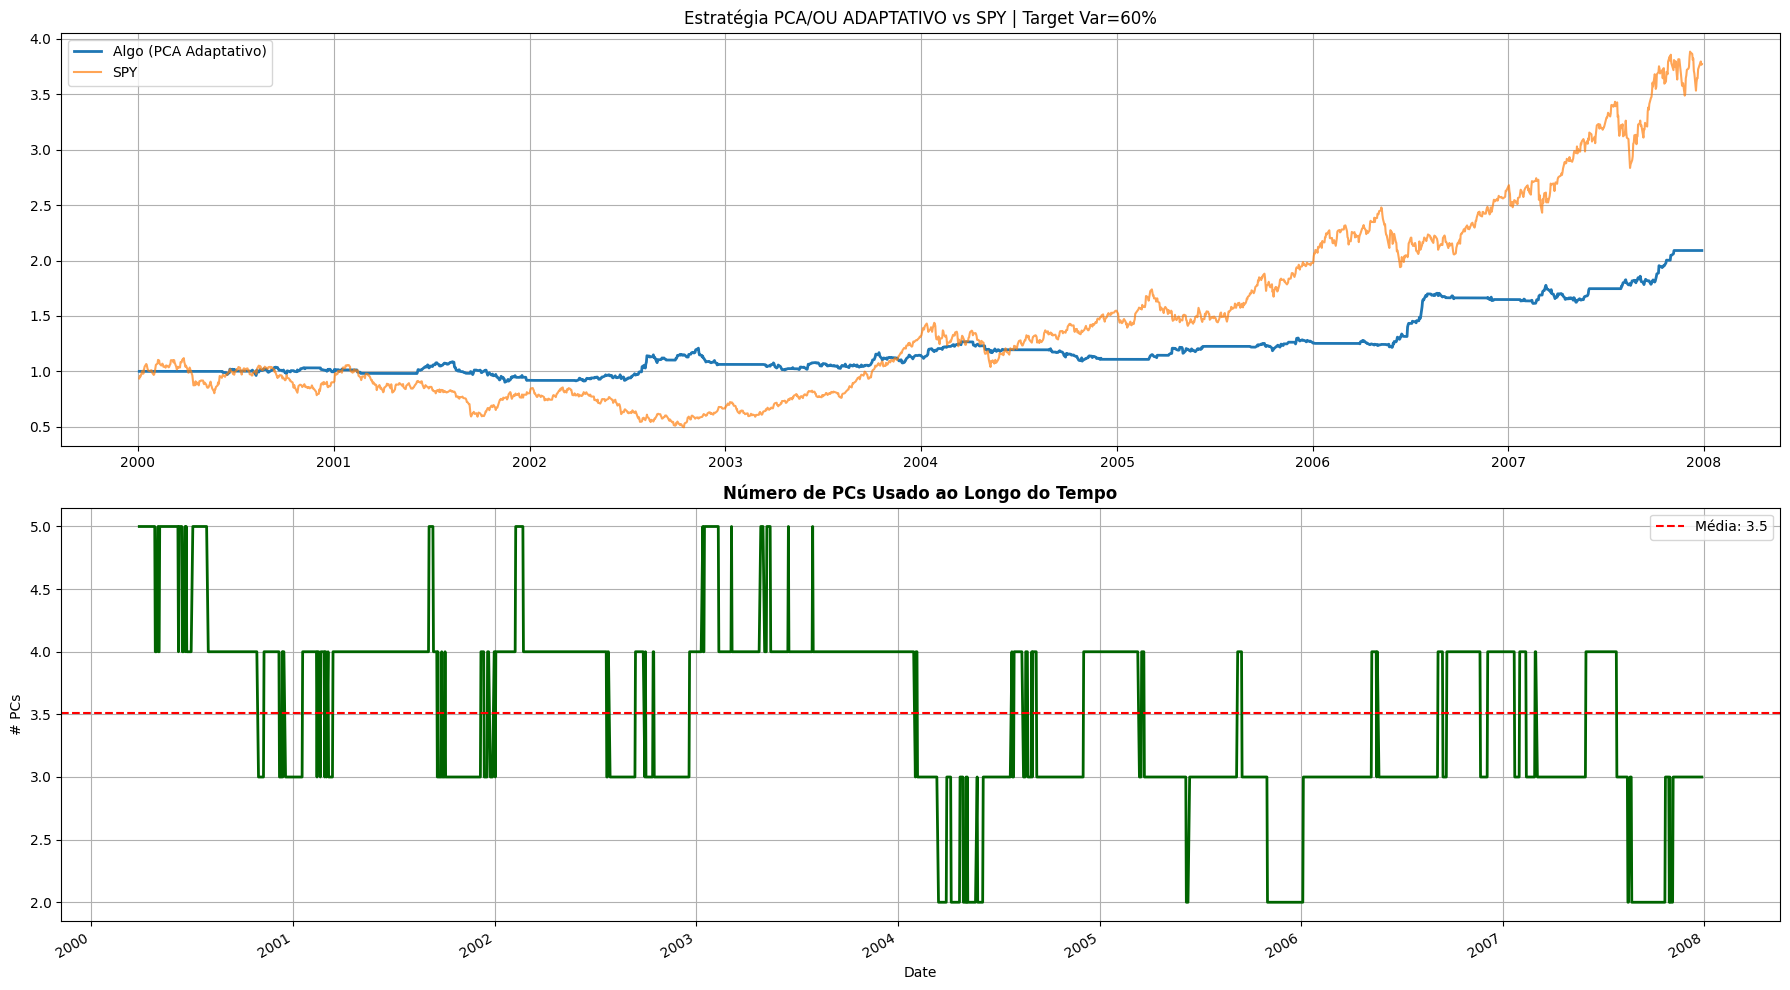

In [13]:
results4 = pca_portfolio_spy_adaptive_pcs(
    returns = returns,
    returns_spy = returns_ibov,
    variance_target = 0.60,  
    min_pcs = 1,
    max_pcs = 35,
    s_win = 60,
    adaptive_thresholds = True,
    adaptive_window = 252,
    percentile_open = 0.15,
    percentile_close_short = 0.35,
    percentile_close_long = 0.45,
    # thresholds fixos
    sbo = 1.25,
    sso = 1.25,
    sbc = 0.50,
    ssc = 0.50,
    eps_cost = 0.0005,
    rebalanceamento_dias = 1,
    plot = True,
)

In [ ]:
results4

{'cumret_algo': Date
 2000-01-04     1.000000
 2000-01-05     1.000000
 2000-01-06     1.000000
 2000-01-07     1.000000
 2000-01-10     1.000000
                 ...    
 2007-12-20    65.174699
 2007-12-21    65.703264
 2007-12-26    65.951477
 2007-12-27    65.798354
 2007-12-28    66.612104
 Length: 2055, dtype: float64,
 'cumret_spy': Ticker         ^BVSP
 Date                
 2000-01-04  0.936267
 2000-01-05  0.959539
 2000-01-06  0.951388
 2000-01-07  0.963320
 2000-01-10  1.005434
 ...              ...
 2007-12-20  3.645363
 2007-12-21  3.726994
 2007-12-26  3.797283
 2007-12-27  3.766923
 2007-12-28  3.773538
 
 [2055 rows x 1 columns],
 's_scores':             BBAS3.SA  BBDC3.SA  BRAP4.SA  BRKM5.SA  CMIG4.SA  CPFE3.SA  \
 Date                                                                     
 2000-05-08  0.030078  0.584709 -0.090267  0.709206  0.934600  0.217227   
 2000-05-09  0.254721  0.533750  0.127959  0.640885  0.715697  0.986570   
 2000-05-10 -0.004360  0.218094  

In [ ]:
cum = results4["cumret_algo"]
jump = cum.pct_change()
print(jump.nlargest(10))   # maiores saltos positivos
print(jump.nsmallest(10))  # maiores quedas

Date
2006-07-24    0.069388
2006-06-27    0.065316
2000-08-10    0.050669
2005-12-02    0.046665
2002-08-06    0.036050
2001-01-03    0.035533
2006-07-25    0.034634
2002-07-30    0.034607
2000-06-21    0.034017
2002-04-04    0.033805
dtype: float64
Date
2001-10-15   -0.076825
2005-03-09   -0.071017
2005-03-10   -0.044428
2004-04-30   -0.041946
2001-08-17   -0.035690
2005-05-04   -0.034841
2001-10-19   -0.033107
2001-11-16   -0.029361
2005-09-06   -0.028125
2002-06-27   -0.027411
dtype: float64


In [ ]:
t0 = jump.abs().idxmax()
w = results4["w_all"].shift(1).loc[t0]         # peso aplicado
r = pd.concat([returns, results4["Factor_PCA"]], axis=1).loc[t0].fillna(0.0)

contrib = (w * r).sort_values(key=np.abs, ascending=False)
print("Dia do salto:", t0)
print("Retorno do dia (aprox):", (w*r).sum())
print(contrib.head(20))

Dia do salto: 2001-10-15 00:00:00
Retorno do dia (aprox): -0.07677780684778993
BRAP4.SA   -0.090767
eig1        0.010556
eig2        0.003490
eig3       -0.000057
BBAS3.SA    0.000000
GOAU4.SA    0.000000
BBDC3.SA    0.000000
CSNA3.SA    0.000000
CYRE3.SA    0.000000
PETR4.SA    0.000000
PETR3.SA    0.000000
ITSA4.SA    0.000000
SBSP3.SA    0.000000
VIVT3.SA    0.000000
VALE3.SA    0.000000
USIM5.SA    0.000000
WEGE3.SA    0.000000
eig4        0.000000
eig5        0.000000
eig6        0.000000
Name: 2001-10-15 00:00:00, dtype: float64


In [48]:
# t0 = pd.Timestamp("2003-10-22")

# w_prev = results3["w_all"].shift(1).loc[t0, "BRKM5.SA"]
# r_day  = returns.loc[t0, "BRKM5.SA"]

# print("w_prev BRKM5:", w_prev)
# print("r_day  BRKM5:", r_day)
# print("produto:", w_prev * r_day)

# # também veja se o retorno é outlier no histórico
# print("max ret BRKM5:", returns["BRKM5.SA"].max())
# print("min ret BRKM5:", returns["BRKM5.SA"].min())

### Teste para longo prazo

In [46]:
# Carregar dados
start_date2 = "2000-01-03"
end_date2 = "2025-12-31"

data_longa = pd.read_csv("precos_1997_2025.csv", index_col=0)
data_longa.index = pd.to_datetime(data_longa.index)
data_longa = data_longa.sort_index()

returns_longa = data_longa.pct_change()
returns_longa.dropna(inplace=True,axis=0, how='all')
returns_longa.dropna(inplace=True,axis=1, how='any')
#returns = returns.loc[start_date:end_date]

# Ibovespa no Yahoo é ^BVSP
data_ibov_longa = yf.download("^BVSP", start=start_date2, end=end_date2, auto_adjust=True, progress=False)["Close"]
data_ibov_longa.index = pd.to_datetime(data_ibov_longa.index).tz_localize(None)
data_ibov_longa = data_ibov_longa.sort_index()

returns_ibov_longa = data_ibov_longa.pct_change().dropna()
returns_ibov_longa.name = "IBOV"

# Garantir que ambos os DataFrames tenham índices coerentes e ordenados (sem timezone)
returns_longa.index     = pd.to_datetime(returns_longa.index).tz_localize(None)
returns_ibov_longa.index = pd.to_datetime(returns_ibov_longa.index).tz_localize(None)
returns_longa     = returns_longa.sort_index()
returns_ibov_longa = returns_ibov_longa.sort_index()

C:\Users\savio\AppData\Local\Temp\ipykernel_8688\1297118825.py:9: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_longa = data_longa.pct_change()


In [47]:
bad_tickers2 = ["CPFE3.SA"]

for col in data_longa.columns:
    p = data_longa[col]
    if p.min() <= 0:
        bad_tickers2.append(col)
        continue
    if (p.max() / p.min()) > 1e3:  # variação absurda de escala
        bad_tickers2.append(col)

bad_tickers2

['CPFE3.SA',
 'AZUL4.SA',
 'BRKM5.SA',
 'CMIG4.SA',
 'GGBR4.SA',
 'LREN3.SA',
 'RADL3.SA',
 'UGPA3.SA']

In [48]:
data_longa = data_longa.drop(columns=bad_tickers2, errors="ignore")
returns_longa = returns_longa.drop(columns=bad_tickers2, errors="ignore")

tickers2 = data_longa.columns.tolist()
len(tickers2)

73

Tempo : 2000-03-28 00:00:00
Tempo : 2000-03-29 00:00:00
Tempo : 2000-03-30 00:00:00
Tempo : 2000-03-31 00:00:00
Tempo : 2000-04-03 00:00:00
Tempo : 2000-04-04 00:00:00
Tempo : 2000-04-05 00:00:00
Tempo : 2000-04-06 00:00:00
Tempo : 2000-04-07 00:00:00
Tempo : 2000-04-10 00:00:00
Tempo : 2000-04-11 00:00:00
Tempo : 2000-04-12 00:00:00
Tempo : 2000-04-13 00:00:00
Tempo : 2000-04-14 00:00:00
Tempo : 2000-04-17 00:00:00
Tempo : 2000-04-18 00:00:00
Tempo : 2000-04-19 00:00:00
Tempo : 2000-04-20 00:00:00
Tempo : 2000-04-21 00:00:00
Tempo : 2000-04-24 00:00:00
Tempo : 2000-04-25 00:00:00
Tempo : 2000-04-26 00:00:00
Tempo : 2000-04-27 00:00:00
Tempo : 2000-04-28 00:00:00
Tempo : 2000-05-01 00:00:00
Tempo : 2000-05-02 00:00:00
Tempo : 2000-05-03 00:00:00
Tempo : 2000-05-04 00:00:00
Tempo : 2000-05-05 00:00:00
Tempo : 2000-05-08 00:00:00
Tempo : 2000-05-09 00:00:00
Tempo : 2000-05-10 00:00:00
Tempo : 2000-05-11 00:00:00
Tempo : 2000-05-12 00:00:00
Tempo : 2000-05-15 00:00:00
Tempo : 2000-05-16 0

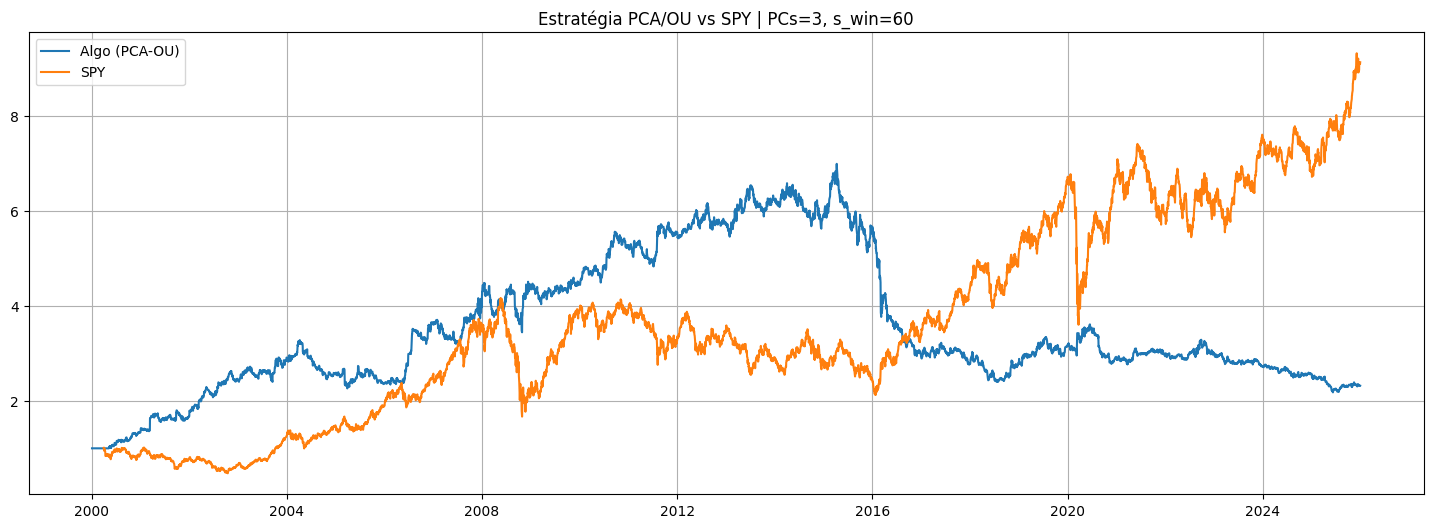

In [49]:
# Melhor longo

results_long = pca_portfolio_spy_hedge(
    returns=returns_longa,
    returns_spy=returns_ibov_longa,
    num_pc=3,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    #kappa_min=8.4, # padrão
    #kappa_min=5.0,
    kappa_min=10.0,
    plot=True
)


PERFORMANCE DA ESTRATÉGIA (1999-2025)
  CAGR      :     0.0330 (   3.30%)
  Vol       :     0.1654 (  16.54%)
  Sharpe    :     0.1996 (  19.96%)
  MaxDD     :    -0.6884 ( -68.84%)


🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 
ANÁLISE DE NEUTRALIDADE DA ESTRATÉGIA
🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 


 Regredindo PnL contra fatores...

REGRESSÃO: RETORNO DA ESTRATÉGIA vs FATORES PCA
  R² (variância explicada por fatores): 0.0031 (0.31%)
  Alpha anualizado (excesso de retorno):  0.0464 (4.64%)
  Alpha diário médio:                      0.000184

  Beta médio (|valor|):                    0.0313
  Beta máximo (|valor|):                   0.0505 (fator: eig3)

📊 Interpretação:
  ✅ EXCELENTE: R² < 5% → Estratégia é genuinamente market-neutral!
     A maior parte do retorno vem de alpha idiossincrático.

  ⚠️  Alpha marginal (4.64%/ano)


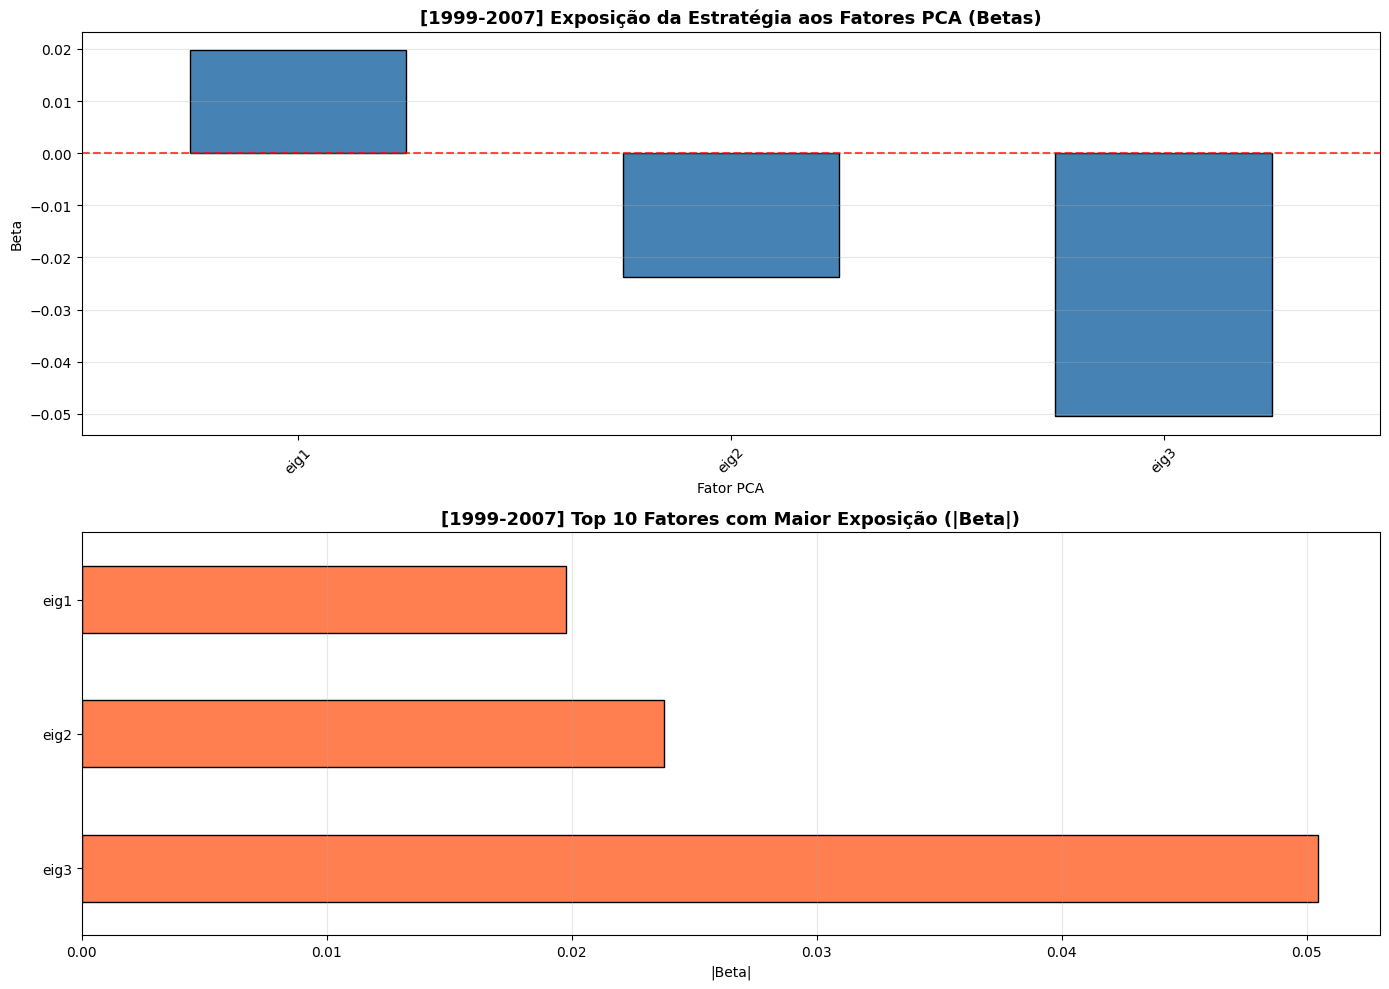


✅ Análise concluída!


📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 
ANÁLISE POR SUBPERÍODOS
📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 


Subperíodo: 1997-2002
  CAGR      :     0.3310 (  33.10%)
  Vol       :     0.1968 (  19.68%)
  Sharpe    :     1.6817 ( 168.17%)
  MaxDD     :    -0.1218 ( -12.18%)

Subperíodo: 2003-2007
  CAGR      :     0.1019 (  10.19%)
  Vol       :     0.1887 (  18.87%)
  Sharpe    :     0.5400 (  54.00%)
  MaxDD     :    -0.3101 ( -31.01%)

Subperíodo: 2008-2012
  CAGR      :     0.0773 (   7.73%)
  Vol       :     0.1541 (  15.41%)
  Sharpe    :     0.5018 (  50.18%)
  MaxDD     :    -0.2318 ( -23.18%)

Subperíodo: 2013-2019
  CAGR      :    -0.0830 (  -8.30%)
  Vol       :     0.1703 (  17.03%)
  Sharpe    :    -0.4873 ( -48.73%)
  MaxDD     :    -0.6568 ( -65.68%)

Subperíodo: 2020-2025
  CAGR      :    -0.0500 (  -5.00%)
  Vol       :     0.1237 (  12.37%)
  Sharpe    :    -0.4037 ( -40.37%)
  MaxDD   

In [50]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net_long = results_long['ret_net']
stats_long = stats_from_returns(ret_net_long)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2025)")
print("="*70)
for k, v in stats_long.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")

# =============================================================================
# 4. ANÁLISE DE NEUTRALIDADE ⭐ NOVO
# =============================================================================

analysis_results = analyze_strategy(
    algo_weights=results_long['algo_weights'],
    betas=results_long['betas'],
    ret_net=results_long['ret_net'],
    Factor_PCA=results_long['Factor_PCA'],
    pcs=results_long['pcs'],
    plot=True,
    title_prefix="[1999-2007] "
)

# =============================================================================
# 5. ANÁLISE POR SUBPERÍODOS (OPCIONAL)
# =============================================================================

print("\n" + "📅 "*35)
print("ANÁLISE POR SUBPERÍODOS")
print("📅 "*35 + "\n")

subperiods_long = [
    ("1997-2002", "1997-01-01", "2002-12-31"),
    ("2003-2007", "2003-01-01", "2007-12-31"),
    ("2008-2012", "2008-01-01", "2012-12-31"),
    ("2013-2019", "2013-01-01", "2019-12-31"),
    ("2020-2025", "2020-01-01", "2025-12-31"),
]

for label, start, end in subperiods_long:
    print(f"\n{'='*70}")
    print(f"Subperíodo: {label}")
    print(f"{'='*70}")
    
    mask = (ret_net_long.index >= start) & (ret_net_long.index <= end)
    ret_sub = ret_net_long[mask]

    if len(ret_sub) < 100:
        print("⚠️  Dados insuficientes")
        continue
    
    stats_sub = stats_from_returns(ret_sub)
    for k, v in stats_sub.items():
        print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")

Tempo : 2000-03-28 00:00:00
Tempo : 2000-03-29 00:00:00
Tempo : 2000-03-30 00:00:00
Tempo : 2000-03-31 00:00:00
Tempo : 2000-04-03 00:00:00
Tempo : 2000-04-04 00:00:00
Tempo : 2000-04-05 00:00:00
Tempo : 2000-04-06 00:00:00
Tempo : 2000-04-07 00:00:00
Tempo : 2000-04-10 00:00:00
Tempo : 2000-04-11 00:00:00
Tempo : 2000-04-12 00:00:00
Tempo : 2000-04-13 00:00:00
Tempo : 2000-04-14 00:00:00
Tempo : 2000-04-17 00:00:00
Tempo : 2000-04-18 00:00:00
Tempo : 2000-04-19 00:00:00
Tempo : 2000-04-20 00:00:00
Tempo : 2000-04-21 00:00:00
Tempo : 2000-04-24 00:00:00
Tempo : 2000-04-25 00:00:00
Tempo : 2000-04-26 00:00:00
Tempo : 2000-04-27 00:00:00
Tempo : 2000-04-28 00:00:00
Tempo : 2000-05-01 00:00:00
Tempo : 2000-05-02 00:00:00
Tempo : 2000-05-03 00:00:00
Tempo : 2000-05-04 00:00:00
Tempo : 2000-05-05 00:00:00
Tempo : 2000-05-08 00:00:00
Tempo : 2000-05-09 00:00:00
Tempo : 2000-05-10 00:00:00
Tempo : 2000-05-11 00:00:00
Tempo : 2000-05-12 00:00:00
Tempo : 2000-05-15 00:00:00
Tempo : 2000-05-16 0

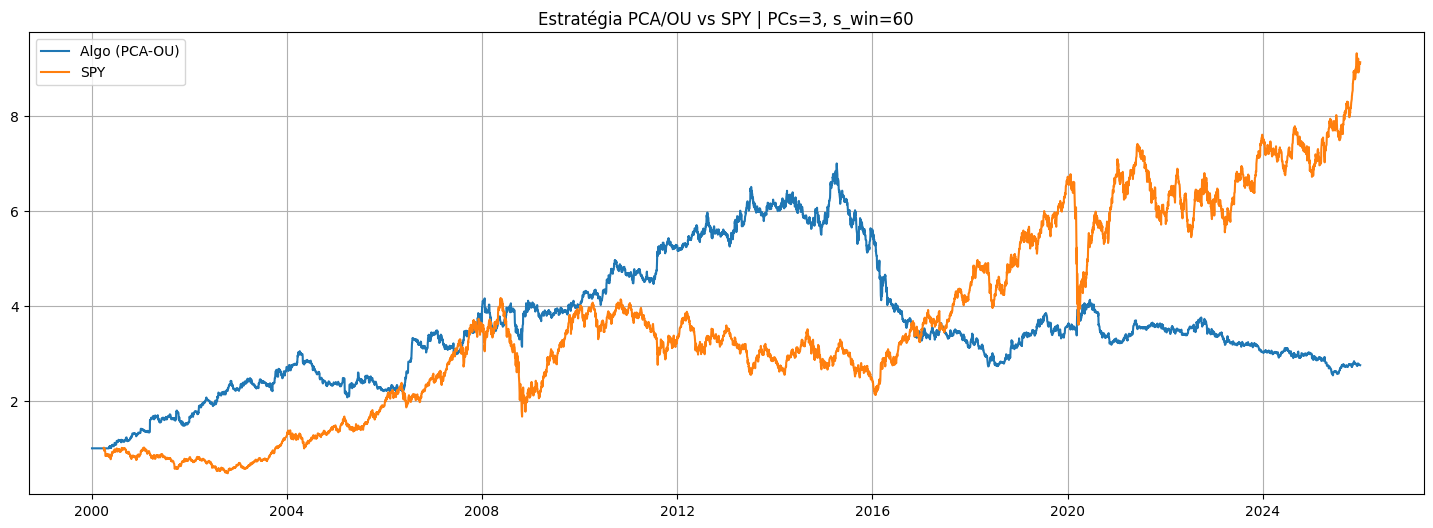

In [51]:
# Melhor longo

results_long = pca_portfolio_spy_hedge(
    returns=returns_longa,
    returns_spy=returns_ibov_longa,
    num_pc=3,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    #kappa_min=8.4, # padrão
    kappa_min=5.0,
    #kappa_min=10.0,
    plot=True
)


PERFORMANCE DA ESTRATÉGIA (1999-2025)
  CAGR      :     0.0398 (   3.98%)
  Vol       :     0.1651 (  16.51%)
  Sharpe    :     0.2414 (  24.14%)
  MaxDD     :    -0.6376 ( -63.76%)


🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 
ANÁLISE DE NEUTRALIDADE DA ESTRATÉGIA
🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 


 Regredindo PnL contra fatores...

REGRESSÃO: RETORNO DA ESTRATÉGIA vs FATORES PCA
  R² (variância explicada por fatores): 0.0040 (0.40%)
  Alpha anualizado (excesso de retorno):  0.0526 (5.26%)
  Alpha diário médio:                      0.000209

  Beta médio (|valor|):                    0.0341
  Beta máximo (|valor|):                   0.0600 (fator: eig3)

📊 Interpretação:
  ✅ EXCELENTE: R² < 5% → Estratégia é genuinamente market-neutral!
     A maior parte do retorno vem de alpha idiossincrático.

  ✅ Alpha positivo (5.26%/ano) → Estratégia gera valor!


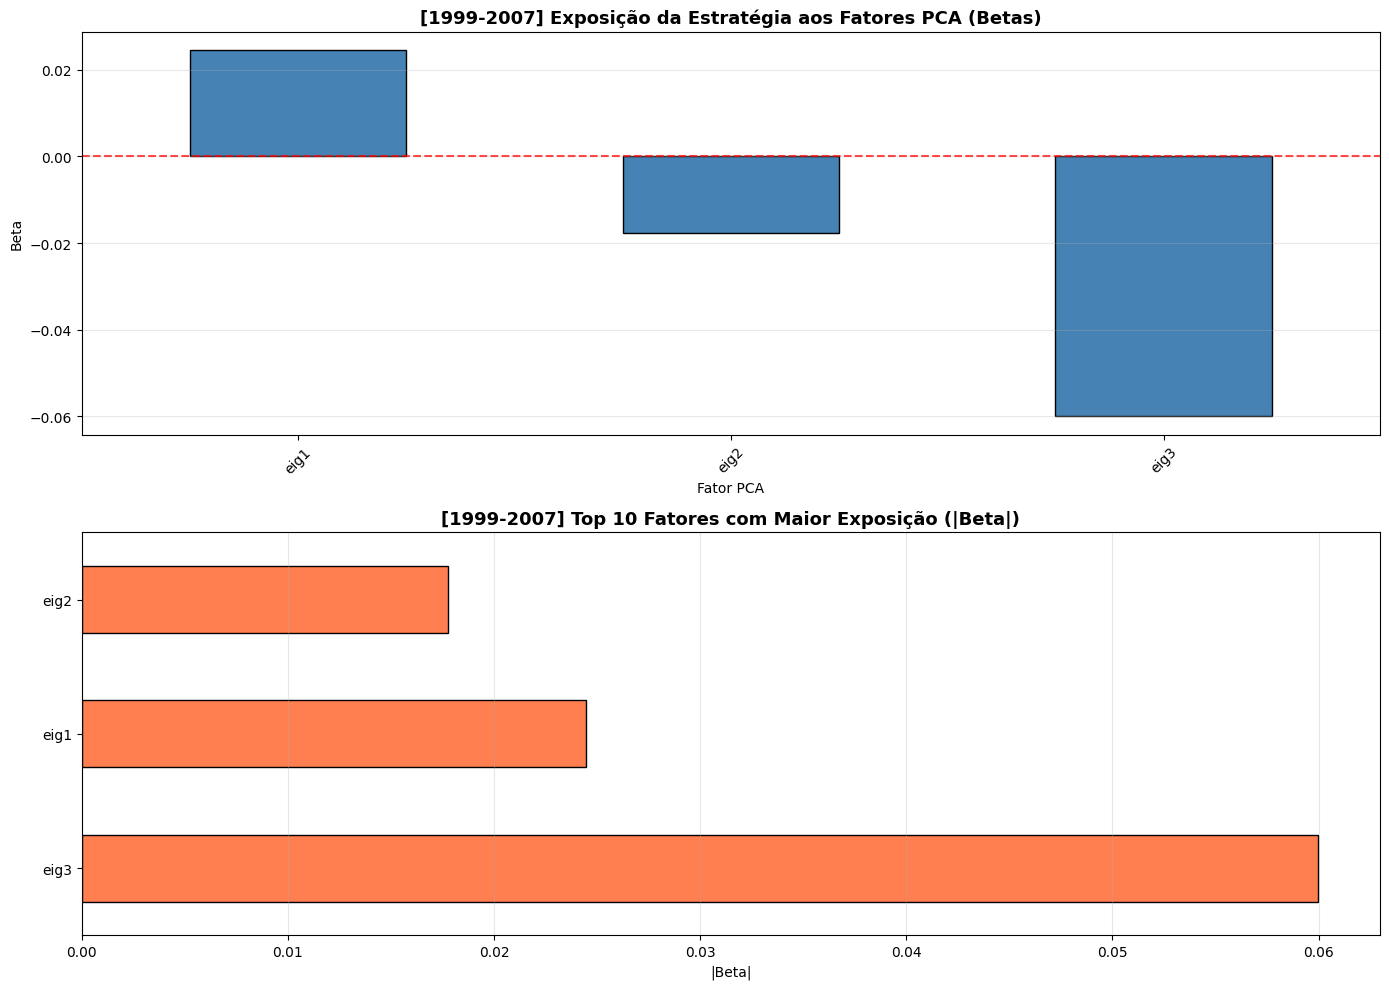


✅ Análise concluída!


📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 
ANÁLISE POR SUBPERÍODOS
📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 


Subperíodo: 1997-2002
  CAGR      :     0.2959 (  29.59%)
  Vol       :     0.2007 (  20.07%)
  Sharpe    :     1.4739 ( 147.39%)
  MaxDD     :    -0.1779 ( -17.79%)

Subperíodo: 2003-2007
  CAGR      :     0.1028 (  10.28%)
  Vol       :     0.1919 (  19.19%)
  Sharpe    :     0.5359 (  53.59%)
  MaxDD     :    -0.3196 ( -31.96%)

Subperíodo: 2008-2012
  CAGR      :     0.0861 (   8.61%)
  Vol       :     0.1543 (  15.43%)
  Sharpe    :     0.5580 (  55.80%)
  MaxDD     :    -0.2451 ( -24.51%)

Subperíodo: 2013-2019
  CAGR      :    -0.0611 (  -6.11%)
  Vol       :     0.1657 (  16.57%)
  Sharpe    :    -0.3687 ( -36.87%)
  MaxDD     :    -0.6109 ( -61.09%)

Subperíodo: 2020-2025
  CAGR      :    -0.0424 (  -4.24%)
  Vol       :     0.1214 (  12.14%)
  Sharpe    :    -0.3492 ( -34.92%)
  MaxDD   

In [52]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net_long = results_long['ret_net']
stats_long = stats_from_returns(ret_net_long)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2025)")
print("="*70)
for k, v in stats_long.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")

# =============================================================================
# 4. ANÁLISE DE NEUTRALIDADE ⭐ NOVO
# =============================================================================

analysis_results = analyze_strategy(
    algo_weights=results_long['algo_weights'],
    betas=results_long['betas'],
    ret_net=results_long['ret_net'],
    Factor_PCA=results_long['Factor_PCA'],
    pcs=results_long['pcs'],
    plot=True,
    title_prefix="[1999-2007] "
)

# =============================================================================
# 5. ANÁLISE POR SUBPERÍODOS (OPCIONAL)
# =============================================================================

print("\n" + "📅 "*35)
print("ANÁLISE POR SUBPERÍODOS")
print("📅 "*35 + "\n")

subperiods_long = [
    ("1997-2002", "1997-01-01", "2002-12-31"),
    ("2003-2007", "2003-01-01", "2007-12-31"),
    ("2008-2012", "2008-01-01", "2012-12-31"),
    ("2013-2019", "2013-01-01", "2019-12-31"),
    ("2020-2025", "2020-01-01", "2025-12-31"),
]

for label, start, end in subperiods_long:
    print(f"\n{'='*70}")
    print(f"Subperíodo: {label}")
    print(f"{'='*70}")
    
    mask = (ret_net_long.index >= start) & (ret_net_long.index <= end)
    ret_sub = ret_net_long[mask]

    if len(ret_sub) < 100:
        print("⚠️  Dados insuficientes")
        continue
    
    stats_sub = stats_from_returns(ret_sub)
    for k, v in stats_sub.items():
        print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")

### Identificando motivo das quedas no longo prazo

<Axes: title={'center': 'Sharpe rolling (252d)'}, xlabel='Date'>

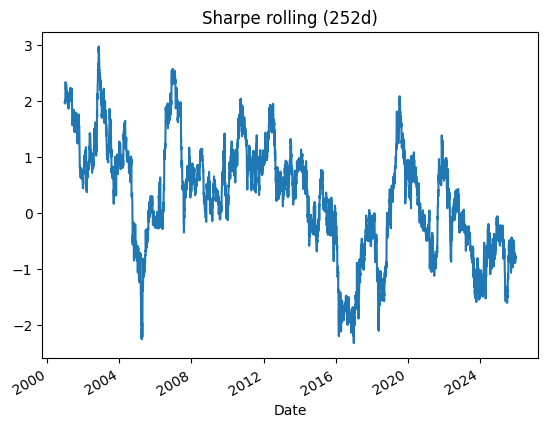

In [55]:
ret = results_long["ret_net"].dropna()

roll = 252  # 1 ano
roll_sharpe = (ret.rolling(roll).mean() / ret.rolling(roll).std()) * np.sqrt(252)
roll_cagr = (1 + ret).rolling(roll).apply(lambda x: (x.prod() ** (252/len(x)) - 1), raw=False)

roll_sharpe.plot(title="Sharpe rolling (252d)")

In [56]:
s_scores = results_long["s_scores"]
algo_w = results_long["algo_weights"]
w_all  = results_long["w_all"]
turn   = results_long["turnover"]

# quantos s-scores válidos por dia
n_scores = s_scores.notna().sum(axis=1)

# quantos longs/shorts por dia (a partir de weights)
n_longs  = (algo_w > 0).sum(axis=1)
n_shorts = (algo_w < 0).sum(axis=1)

# gross exposure (antes/depois do hedge e normalização)
gross_stocks = algo_w.abs().sum(axis=1)
gross_all    = w_all.abs().sum(axis=1)

dbg = pd.DataFrame({
    "n_scores": n_scores,
    "n_longs": n_longs,
    "n_shorts": n_shorts,
    "gross_stocks": gross_stocks,
    "gross_all": gross_all,
    "turnover": turn.reindex(gross_all.index),
})

# agregue por ano pra ver queda estrutural
yearly = dbg.groupby(dbg.index.year).mean()
print(yearly.loc[2005:2025])

       n_scores   n_longs  n_shorts  gross_stocks  gross_all  turnover
Date                                                                  
2005  13.610442  1.863454  1.815261      1.666667   1.000000  0.279009
2006  13.755814  2.364341  1.891473      1.666667   0.926357  0.316762
2007  14.000000  2.244898  2.106122      1.853061   1.000000  0.312116
2008  13.991968  1.662651  1.646586      1.618474   0.971888  0.314447
2009  13.991935  2.681452  2.616935      1.931452   1.000000  0.344002
2010  13.995951  1.991903  2.242915      1.821862   0.991903  0.359994
2011  13.979920  2.184739  2.642570      1.843373   0.983936  0.318598
2012  13.987755  2.730612  2.987755      1.967347   1.000000  0.319774
2013  13.995968  1.778226  2.036290      1.750000   0.983871  0.303043
2014  13.967742  2.000000  2.165323      1.725806   0.979839  0.293434
2015  13.995935  2.784553  2.658537      1.975610   0.995935  0.260238
2016  13.983936  2.369478  2.381526      1.811245   1.000000  0.298972
2017  

In [57]:
F = results_long["Factor_PCA"]
pcs = results_long["pcs"]

pca_ok = F[pcs].notna().all(axis=1)  # todos os PCs presentes
pca_ok_year = pca_ok.groupby(pca_ok.index.year).mean()

print(pca_ok_year.loc[2005:2025])

Date
2005    1.0
2006    1.0
2007    1.0
2008    1.0
2009    1.0
2010    1.0
2011    1.0
2012    1.0
2013    1.0
2014    1.0
2015    1.0
2016    1.0
2017    1.0
2018    1.0
2019    1.0
2020    1.0
2021    1.0
2022    1.0
2023    1.0
2024    1.0
2025    1.0
dtype: float64


In [58]:
w_all = results_long["w_all"].copy()
rets_all = pd.concat([returns_longa, results_long["Factor_PCA"]], axis=1)

common_cols = w_all.columns.intersection(rets_all.columns)
w = w_all[common_cols].reindex(rets_all.index).fillna(0.0)
r = rets_all[common_cols].reindex(w.index)

w_shift = w.shift(1).fillna(0.0)

stock_cols = returns_longa.columns.intersection(common_cols)
pc_cols    = pd.Index(results_long["pcs"]).intersection(common_cols)

ret_stock = (r[stock_cols] * w_shift[stock_cols]).sum(axis=1)
ret_hedge = (r[pc_cols]    * w_shift[pc_cols]).sum(axis=1)

turnover = (w - w.shift(1)).abs().sum(axis=1).fillna(0.0)
cost = 0.0005 * turnover

ret_net_rebuild = ret_stock + ret_hedge - cost

decomp = pd.DataFrame({
    "ret_stock": ret_stock,
    "ret_hedge": ret_hedge,
    "cost": cost,
    "ret_net": results_long["ret_net"].reindex(ret_stock.index),
    "diff": (results_long["ret_net"].reindex(ret_stock.index) - ret_net_rebuild),
})

print(decomp[["diff"]].abs().max())  # deve ser ~0; sanity check
print(decomp.groupby(decomp.index.year)[["ret_stock","ret_hedge","cost"]].mean().loc[2005:2025])

diff    1.387779e-17
dtype: float64
      ret_stock  ret_hedge      cost
Date                                
2005   0.000239  -0.000296  0.000140
2006   0.001852   0.000068  0.000158
2007   0.000495   0.000069  0.000156
2008   0.000327   0.000310  0.000157
2009   0.000246  -0.000044  0.000172
2010   0.000845  -0.000022  0.000180
2011   0.000718  -0.000029  0.000159
2012   0.000301   0.000046  0.000160
2013   0.000716  -0.000068  0.000152
2014  -0.000039  -0.000025  0.000147
2015   0.000150  -0.000084  0.000130
2016  -0.002191   0.000364  0.000149
2017   0.000188  -0.000278  0.000143
2018   0.000246   0.000064  0.000149
2019   0.000721  -0.000079  0.000175
2020  -0.000208   0.000121  0.000138
2021   0.000280   0.000085  0.000159
2022   0.000104   0.000016  0.000125
2023  -0.000486   0.000141  0.000131
2024   0.000200  -0.000097  0.000132
2025  -0.000196   0.000010  0.000139


In [59]:
dd = (1 + results_long["ret_net"]).cumprod()
peak = dd.cummax()
drawdown = dd/peak - 1

worst = drawdown.nsmallest(20)
print(worst)

# Para esses dias, olhe decomposição
print(decomp.loc[worst.index, ["ret_stock","ret_hedge","cost","ret_net"]])

Date
2025-06-09   -0.637637
2025-06-10   -0.635847
2025-06-06   -0.634386
2025-07-11   -0.633501
2025-06-04   -0.632927
2025-06-05   -0.632407
2025-06-11   -0.632257
2025-07-14   -0.632104
2025-07-10   -0.632041
2025-07-22   -0.631961
2025-07-15   -0.631834
2025-07-09   -0.631493
2025-06-03   -0.631406
2025-06-02   -0.631394
2025-07-08   -0.631346
2025-07-21   -0.631239
2025-07-18   -0.630801
2025-05-30   -0.630459
2025-07-16   -0.630388
2025-06-12   -0.630113
dtype: float64
            ret_stock  ret_hedge      cost   ret_net
Date                                                
2025-06-09  -0.008606   0.000044  0.000331 -0.008893
2025-06-10   0.006190  -0.001048  0.000204  0.004938
2025-06-06  -0.005564   0.000359  0.000178 -0.005383
2025-07-11  -0.004193   0.000233  0.000008 -0.003967
2025-06-04  -0.005266   0.001299  0.000161 -0.004128
2025-06-05   0.001011   0.000410  0.000004  0.001417
2025-06-11   0.010782  -0.000709  0.000212  0.009861
2025-07-14   0.002567   0.001255  0.000012 

In [ ]:
#pip install quantstats
import quantstats as qs

#qs.reports.html(cum_algo, output="relatorio.html", title="Relatório da Estratégia")
